# 05 · Overfitting and Pruning

Grow a tree with no limits on noisy data and it drives every leaf to purity, wrapping the boundary around each mislabeled point: 100% train accuracy, poor test accuracy — the most literal picture of overfitting in the series. Then apply the fixes (depth, min-samples, cost-complexity pruning) and watch it un-memorize.

**Artifacts:** `outputs/figures/05_*.png`, `outputs/data/05_*.json`.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from src.config import load_settings
from src.datasets import noisy_blobs
from src.tree.classifier import DecisionTreeClassifier
from src.tree.prune import cost_complexity_prune, n_nodes, tree_depth
from src.evaluation import accuracy, plot_decision_boundary, train_test_accuracy_vs_depth
from src.outputs import save_figure, save_json

SEED = load_settings().seed
RES = 180
X, y = noisy_blobs(n_samples=500, noise=0.25, seed=SEED)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=SEED)

## Memorize, then regularize
Left: an unlimited tree. Right: the same tree held back (max_depth=3, min_samples_leaf=10).

unlimited: {'train': 1.0, 'test': 0.6533333333333333, 'n_nodes': 209, 'depth': 23}
limited  : {'train': 0.7428571428571429, 'test': 0.66, 'n_nodes': 13, 'depth': 3}


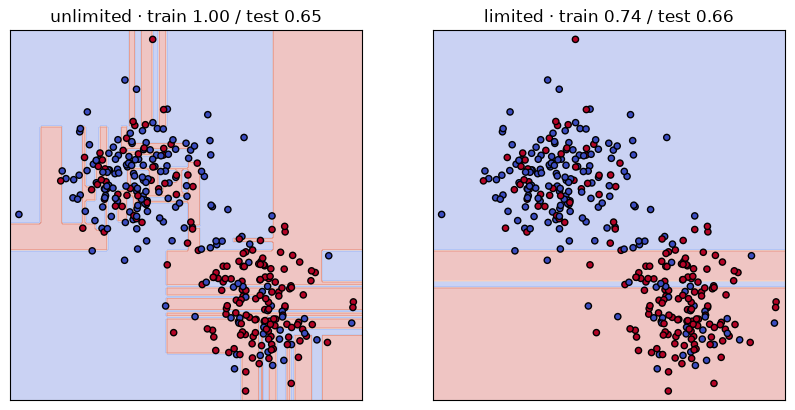

In [2]:
full = DecisionTreeClassifier(max_depth=None).fit(X_tr, y_tr)
limited = DecisionTreeClassifier(max_depth=3, min_samples_leaf=10).fit(X_tr, y_tr)

def scores(model):
    return {'train': accuracy(y_tr, model.predict(X_tr)), 'test': accuracy(y_te, model.predict(X_te)),
            'n_nodes': n_nodes(model.root_), 'depth': tree_depth(model.root_)}

full_s, limited_s = scores(full), scores(limited)
fig, axes = plt.subplots(1, 2, figsize=(10, 4.8))
plot_decision_boundary(full, X_tr, y_tr, ax=axes[0], resolution=RES,
                       title=f"unlimited · train {full_s['train']:.2f} / test {full_s['test']:.2f}")
plot_decision_boundary(limited, X_tr, y_tr, ax=axes[1], resolution=RES,
                       title=f"limited · train {limited_s['train']:.2f} / test {limited_s['test']:.2f}")
save_figure(fig, '05_boundaries')
print('unlimited:', full_s)
print('limited  :', limited_s)

## The train–test gap versus depth
The classic overfitting curve: training accuracy marches to 1.0 while test accuracy peaks early and then decays. The widening gap is the memorization.

PosixPath('/workspaces/decision_trees_101/outputs/figures/05_gap_vs_depth.png')

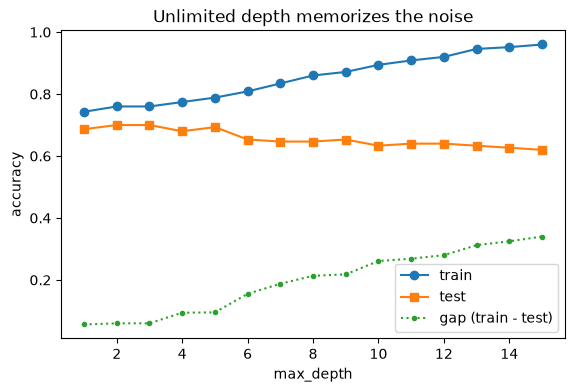

In [3]:
rows = train_test_accuracy_vs_depth(X_tr, y_tr, X_te, y_te, depths=range(1, 16))
ds = [r['depth'] for r in rows]
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(ds, [r['train'] for r in rows], marker='o', label='train')
ax.plot(ds, [r['test'] for r in rows], marker='s', label='test')
ax.plot(ds, [r['gap'] for r in rows], marker='.', ls=':', label='gap (train - test)')
ax.set(xlabel='max_depth', ylabel='accuracy', title='Unlimited depth memorizes the noise')
ax.legend()
save_figure(fig, '05_gap_vs_depth')

## Cost-complexity pruning
Post-prune the unlimited tree at a range of α. As α grows the tree shrinks; test accuracy typically rises before the tree collapses to its root.

PosixPath('/workspaces/decision_trees_101/outputs/figures/05_ccp_path.png')

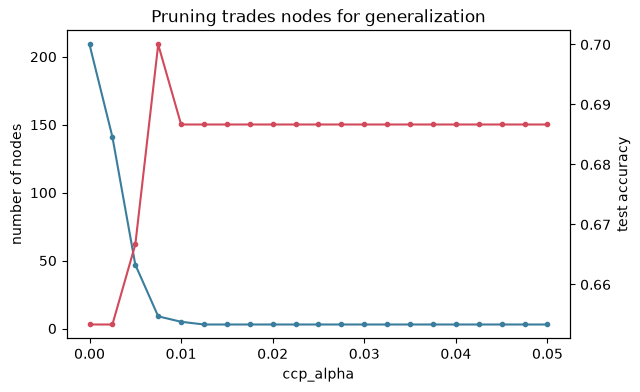

In [4]:
alphas = np.linspace(0.0, 0.05, 21)
path = []
for a in alphas:
    p = cost_complexity_prune(full, float(a))
    path.append({'alpha': float(a), 'n_nodes': n_nodes(p.root_),
                 'train': accuracy(y_tr, p.predict(X_tr)), 'test': accuracy(y_te, p.predict(X_te))})

fig, ax1 = plt.subplots(figsize=(6.5, 4))
ax2 = ax1.twinx()
ax1.plot(alphas, [r['n_nodes'] for r in path], color='#3a7d9c', marker='.', label='nodes')
ax2.plot(alphas, [r['test'] for r in path], color='#d1495b', marker='.', label='test acc')
ax1.set(xlabel='ccp_alpha', ylabel='number of nodes')
ax2.set_ylabel('test accuracy')
ax1.set_title('Pruning trades nodes for generalization')
save_figure(fig, '05_ccp_path')

In [5]:
save_json({'seed': SEED, 'unlimited': full_s, 'limited': limited_s}, '05_unlimited_vs_limited')
save_json({'seed': SEED, 'accuracy_vs_depth': rows}, '05_accuracy_vs_depth')
save_json({'seed': SEED, 'ccp_path': path}, '05_ccp_path')
print('saved 05_unlimited_vs_limited.json, 05_accuracy_vs_depth.json, 05_ccp_path.json')

saved 05_unlimited_vs_limited.json, 05_accuracy_vs_depth.json, 05_ccp_path.json


## Takeaway
Depth limits, minimum samples per leaf, and cost-complexity pruning are the **regularization idea applied to trees** — and they are precisely the ensemble hyperparameters people tune without knowing that is what they are doing.